# Deep Learning (Redes Neuronales Recurrentes) 🧠🔁
**Asignatura**: Unstructured Data Analysis  

**Objetivo**: Escalar la complejidad del análisis capturando el contexto secuencial y las dependencias semánticas de los prompts generados por los LLMs, superando las limitaciones del enfoque tradicional (TF-IDF) mediante el uso de arquitecturas de aprendizaje profundo.

**Arquitectura a evaluar**:

- ``Red Neuronal Recurrente con capas Bi-LSTM (Bidirectional Long Short-Term Memory)``

**Pipeline de Deep Learning**:

1. **Preparación de Secuencias**: Tokenización del texto a nivel de red neuronal (asignación de índices) y aplicación de Padding para unificar la longitud de entrada de todos los prompts.

2. **Capa de Embeddings**: Construcción de la capa de entrada utilizando representaciones vectoriales densas (integrando pesos preentrenados como Word2Vec o GloVe).

3. **Procesamiento Secuencial Bidireccional**: Integración de una o dos capas Bi-LSTM para procesar el texto en ambas direcciones (pasado-futuro y futuro-pasado), capturando el contexto completo de cada palabra.

4. **Clasificación Multiclase**: Capa Densa (Dense) de salida con activación Softmax y función de pérdida Categorical Cross-Entropy.

5. **Entrenamiento**: Ajuste de pesos del modelo dividiendo el conjunto de entrenamiento (con un pequeño validation split) y usando callbacks como Early Stopping para evitar el sobreajuste.

6. **Evaluación**: Análisis de resultados sobre el conjunto de Test (Out-of-Distribution) y comparación directa de rendimiento frente al Baseline de Machine Learning clásico.

---
## 0. Setup e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


MODEL_SHORT = {
    'x-ai/grok-3-mini':                 'Grok-3-mini',
    'openai/gpt-4.1-nano':              'GPT-4.1-nano',
    'mistralai/mixtral-8x7b-instruct':  'Mixtral-8x7b',
    'meta-llama/llama-3.2-1b-instruct': 'Llama-3.2-1b',
    'google/gemini-2.5-flash-lite':     'Gemini-2.5-lite',
}

# Comprobamos si la instalación de cu118 está funcionando
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Dispositivo de entrenamiento: {device}")
if device.type == 'cuda':
    print(f"Gráfica detectada: {torch.cuda.get_device_name(0)}")

🚀 Dispositivo de entrenamiento: cuda
Gráfica detectada: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
print(torch.__version__)

2.7.1+cu118


---
## 1. Carga del Dataset

In [3]:
DATA_PATH = '../datasets/dataset_preprocesado.csv.xls'

df = pd.read_csv(DATA_PATH, low_memory=False)
df['model_short'] = df['model'].map(MODEL_SHORT)

print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
print(f"Modelos: {df['model_short'].unique().tolist()}")
print(f"Nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head(3)

Filas: 45,481 | Columnas: 12
Modelos: ['GPT-4.1-nano', 'Llama-3.2-1b', 'Gemini-2.5-lite', 'Mixtral-8x7b', 'Grok-3-mini']
Nulos por columna:
text_clean         1
text_lemmatized    1
dtype: int64


,iteration,topic,seed_model,model,question,text,timestamp,response_time_s,tokens_approx,text_clean,text_lemmatized,model_short
0,1,space exploration,google/gemini-2.5-flash-lite,openai/gpt-4.1-nano,What are the primary challenges facing the lon...,The long-term sustainability of human settleme...,2026-02-23T19:16:11.692706,4.94,440,The longterm sustainability of human settlemen...,the longterm sustainability of human settlemen...,GPT-4.1-nano
1,1,space exploration,google/gemini-2.5-flash-lite,meta-llama/llama-3.2-1b-instruct,What are the primary challenges facing the lon...,The primary challenges facing the long-term su...,2026-02-23T19:16:12.049284,5.29,463,The primary challenges facing the longterm sus...,the primary challenges facing the longterm sus...,Llama-3.2-1b
2,1,space exploration,google/gemini-2.5-flash-lite,google/gemini-2.5-flash-lite,What are the primary challenges facing the lon...,The long-term sustainability of human settleme...,2026-02-23T19:16:16.162103,4.47,600,The longterm sustainability of human settlemen...,the longterm sustainability of human settlemen...,Gemini-2.5-lite


---
## 2. Preparación y División de Datos

In [4]:
df_clean = df.drop_duplicates(subset=['question', 'model_short'], keep='first')
df_clean = df_clean.drop_duplicates(subset=['text_clean'], keep='first')

# Aseguramos que no haya nulos en text_clean
df_clean['text_clean'] = df_clean['text_clean'].fillna('')

print(f"Filas originales: {len(df):,} | Tras limpieza: {len(df_clean):,}")

Filas originales: 45,481 | Tras limpieza: 19,421


### 2.1. División de los Datos

In [5]:
topic_reservado = 'space exploration'
print(f"Tema reservado para Test (OOD): '{topic_reservado}'")

df_train = df_clean[df_clean['topic'] != topic_reservado]
df_test = df_clean[df_clean['topic'] == topic_reservado]

# ¡USAMOS TEXT_CLEAN AQUÍ!
X_train = df_train['text_clean'].values
y_train = df_train['model_short'].values
X_test = df_test['text_clean'].values
y_test = df_test['model_short'].values

print(f"Textos Train: {len(X_train):,} | Textos Test: {len(X_test):,}")

Tema reservado para Test (OOD): 'space exploration'
Textos Train: 17,842 | Textos Test: 1,579


---
# 3. Vocabulario y Padding 

In [6]:
MAX_VOCAB_SIZE = 20000 
MAX_SEQ_LEN = 200

print("Construyendo vocabulario desde text_clean...")
all_words = [word for text in X_train for word in text.split()]
word_counts = Counter(all_words)

# Diccionario (0=PAD, 1=UNK, resto=palabras)
vocab = {word: i+2 for i, (word, _) in enumerate(word_counts.most_common(MAX_VOCAB_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def encode_and_pad(text):
    seq = [vocab.get(word, vocab['<UNK>']) for word in text.split()]
    if len(seq) < MAX_SEQ_LEN:
        seq = seq + [vocab['<PAD>']] * (MAX_SEQ_LEN - len(seq))
    else:
        seq = seq[:MAX_SEQ_LEN]
    return seq

X_train_seq = np.array([encode_and_pad(t) for t in X_train])
X_test_seq = np.array([encode_and_pad(t) for t in X_test])

print(f"Tamaño del vocabulario: {len(vocab):,} palabras únicas")

Construyendo vocabulario desde text_clean...
Tamaño del vocabulario: 20,002 palabras únicas


---
# 4. DataLoaders y Modelo Bi-LSTM

### **4.1 DataLoader**

In [ ]:
# Etiquetas a números
label_encoder = LabelEncoder()
y_train_idx = label_encoder.fit_transform(y_train)
y_test_idx = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# Dataset Pytorch
class PromptDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(PromptDataset(X_train_seq, y_train_idx), batch_size=32, shuffle=True)
test_loader = DataLoader(PromptDataset(X_test_seq, y_test_idx), batch_size=32, shuffle=False)

### **4.2 Modelo Bi-LSTM**

#### **4.2.1. Arquitectura Inicial de Deep Learning (Modelo con Sobreajuste)**
En la primera fase de experimentación con redes neuronales, se diseñó una arquitectura Bi-LSTM estándar con una alta capacidad de representación. La configuración de este primer modelo fue la siguiente:

- **Capa de Entrada (Embedding)**: Dimensión vectorial de 128 para representar el vocabulario de los textos.
- **Procesamiento Secuencial**: Una única capa Bi-LSTM con 64 unidades ocultas por dirección (128 en total al concatenar el paso hacia adelante y hacia atrás).
- **Regularización**: Un Dropout moderado del 30% (0.3) aplicado únicamente antes de la capa final de clasificación.
- **Optimizador**: Adam estándar, sin penalización por pesos grandes (Weight Decay = 0).

Tras esta primera iteración de entrenamiento, el modelo alcanzó una precisión del **100%** en el conjunto de **entrenamiento**, pero un **85%** en el conjunto de **test** (Out-of-Distribution sobre el tema "Space Exploration"). Esta brecha métrica es un claro indicador de **sobreajuste** (overfitting): la red disponía de tanta capacidad (memoria RAM interna) que comenzó a memorizar el vocabulario específico de los textos de entrenamiento en lugar de generalizar las huellas estilísticas de cada LLM.

#### **4.2.2. Optimización y Mitigación del Sobreajuste**
Para forzar al modelo a olvidar el vocabulario específico y aprender patrones sintácticos y estructurales profundos, se rediseñó la arquitectura aplicando tres estrategias agresivas de regularización:

##### **A. Regularización mediante Dropout Agresivo y Profundidad Secuencial**
Se incrementó la tasa de Dropout del 30% al 50% y se añadió una segunda capa LSTM.

Al apilar dos capas recurrentes (Stacked Bi-LSTM), permitimos que la primera capa procese las relaciones secuenciales a corto plazo (palabra por palabra), mientras que la segunda capa extrae patrones más abstractos y de alto nivel (el "tono" o la "estructura" de la frase).

Al aplicar un Dropout del 50% entre estas capas, apagamos aleatoriamente la mitad de las neuronas en cada pasada. Esto induce una "amnesia selectiva" que impide que la red dependa de caminos neuronales específicos o de palabras concretas, obligándola a desarrollar múltiples formas de identificar a una IA basándose en el esqueleto completo del texto.

##### **B. Regularización L2 (Weight Decay)**
Se introdujo el parámetro weight_decay en el optimizador Adam. Esta técnica matemática penaliza los pesos (weights) que crecen demasiado. Si la red intenta darle una importancia desproporcionada a una sola palabra (por ejemplo, si asocia erróneamente el uso de la palabra "Summary" exclusivamente a un modelo), el optimizador restará puntuación a ese peso. Esto fuerza a la red a distribuir su atención a lo largo de toda la secuencia de texto, tomando decisiones más equilibradas.

##### **C. Reducción de Dimensionalidad**
Se redujo drásticamente la capacidad de memorización de la red limitando sus parámetros. La dimensión de los Embeddings se redujo de 128 a 64, y las unidades ocultas de la LSTM de 64 a 32. Al crear este cuello de botella, el modelo ya no tiene espacio suficiente para memorizar el ruido o los detalles irrelevantes de los datos de entrenamiento. Solo la información más crítica y distintiva sobre el estilo de los LLMs logrará pasar a través de la red para realizar la clasificación.

#### **4.2.3. Arquitectura Final del Modelo Bi-LSTM**
Tras aplicar estas optimizaciones, la red neuronal definitiva sigue el siguiente flujo de procesamiento secuencial:

- **Capa de Entrada (Embedding Layer)**: Vocabulario limitado a los tokens más relevantes.
- **Dimensión**: 64 (Representación vectorial densa de cada palabra).
- **Capa Recurrente** (Stacked Bi-LSTM):
    - **Direccionalidad**: Bidireccional (procesa el texto hacia el futuro y hacia el pasado).
    - **Capas**: 2 capas apiladas (num_layers=2).
- **Unidades Ocultas**: 32 por dirección (64 en total tras concatenar).
- **Regularización interna**: Dropout del 50% entre las capas LSTM.
- **Capa de Regularización (Dropout Final)**: Apagado aleatorio del 50% de las conexiones salientes de la LSTM antes de clasificar.
- **Capa de Clasificación (Dense / Fully Connected)**:
    - **Entrada**: Vector de contexto de la última capa oculta.
    - **Salida**: 5 neuronas (una por cada LLM) con función de pérdida Categorical Cross-Entropy.

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Añadimos 2 capas LSTM (num_layers=2) y Dropout entre ellas
        self.lstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=True, 
                            batch_first=True, num_layers=2, dropout=0.5)
        
        # Subimos el Dropout final a 50%
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        # Cogemos las últimas capas ocultas de la última capa LSTM
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden_cat))

# REDUCIMOS las dimensiones: embed_dim a 64 y hidden_dim a 32
model = BiLSTMClassifier(len(vocab), embed_dim=64, hidden_dim=32, num_classes=num_classes).to(device)
print(model)

BiLSTMClassifier(
  (embedding): Embedding(20002, 64, padding_idx=0)
  (lstm): LSTM(64, 32, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)


---
# 5. ENTRENAMIENTO DEL MODELO

In [8]:
criterion = nn.CrossEntropyLoss()
# Añadimos weight_decay para la regularización L2
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 10
train_losses, train_accuracies = [], []

print("Entrenando Bi-LSTM...")
for epoch in range(epochs):
    model.train()
    running_loss, correct_preds, total_preds = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_preds += labels.size(0)
        correct_preds += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct_preds / total_preds
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Época {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

Entrenando Bi-LSTM...
Época 01/10 | Loss: 1.4889 | Accuracy: 0.3343
Época 02/10 | Loss: 0.8503 | Accuracy: 0.6512
Época 03/10 | Loss: 0.6221 | Accuracy: 0.7589
Época 04/10 | Loss: 0.5605 | Accuracy: 0.7992
Época 05/10 | Loss: 0.4223 | Accuracy: 0.8593
Época 06/10 | Loss: 0.3368 | Accuracy: 0.8904
Época 07/10 | Loss: 0.2708 | Accuracy: 0.9179
Época 08/10 | Loss: 0.2412 | Accuracy: 0.9251
Época 09/10 | Loss: 0.1722 | Accuracy: 0.9502
Época 10/10 | Loss: 0.2142 | Accuracy: 0.9332


---
# 6. Evaluación y Gráficos


📊 MÉTRICAS EN TRAIN (Entrenamiento):
                 precision    recall  f1-score   support

   GPT-4.1-nano       0.99      0.96      0.97      3570
Gemini-2.5-lite       0.97      0.99      0.98      3565
    Grok-3-mini       0.98      0.99      0.99      3571
   Llama-3.2-1b       0.93      0.98      0.95      3565
   Mixtral-8x7b       0.98      0.93      0.95      3571

       accuracy                           0.97     17842
      macro avg       0.97      0.97      0.97     17842
   weighted avg       0.97      0.97      0.97     17842


🎯 MÉTRICAS EN TEST (Evaluación / Space Exploration):
                 precision    recall  f1-score   support

   GPT-4.1-nano       0.91      0.87      0.89       315
Gemini-2.5-lite       0.79      0.99      0.88       316
    Grok-3-mini       0.94      0.90      0.92       317
   Llama-3.2-1b       0.81      0.88      0.84       314
   Mixtral-8x7b       0.96      0.74      0.84       317

       accuracy                           0.87  

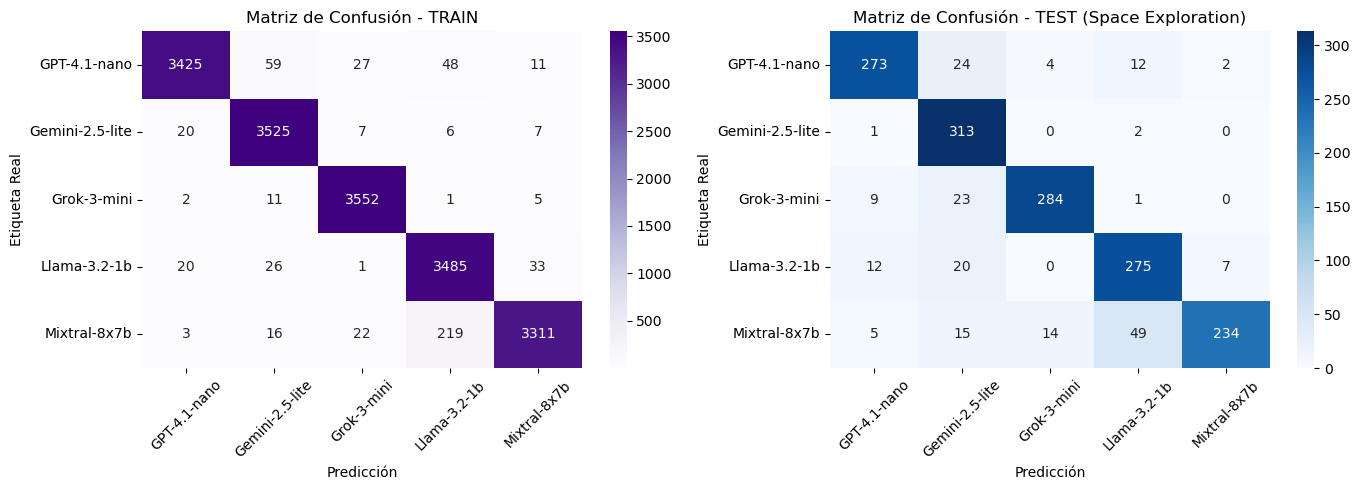

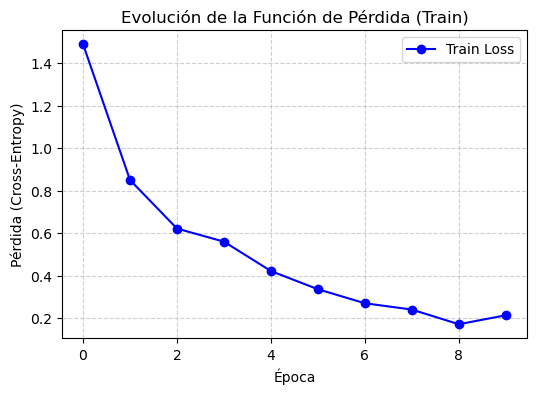

In [9]:
model.eval() # Modo evaluación (apaga el Dropout para predecir)

# --- 1. PREDICCIONES EN TRAIN ---
all_preds_train, all_labels_train = [], []
with torch.no_grad():
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds_train.extend(predicted.cpu().numpy())
        all_labels_train.extend(labels.cpu().numpy())

# --- 2. PREDICCIONES EN TEST (Space Exploration) ---
all_preds_test, all_labels_test = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# --- 3. REPORTES DE CLASIFICACIÓN ---
print(f"\n{'='*55}")
print("📊 MÉTRICAS EN TRAIN (Entrenamiento):")
print(f"{'='*55}")
print(classification_report(all_labels_train, all_preds_train, target_names=label_encoder.classes_))

print(f"\n{'='*55}")
print("🎯 MÉTRICAS EN TEST (Evaluación / Space Exploration):")
print(f"{'='*55}")
print(classification_report(all_labels_test, all_preds_test, target_names=label_encoder.classes_))

# --- 4. MATRICES DE CONFUSIÓN (Subplots) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Train
cm_train = confusion_matrix(all_labels_train, all_preds_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Purples', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title("Matriz de Confusión - TRAIN")
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Predicción')
axes[0].tick_params(axis='x', rotation=45)

# Matriz Test
cm_test = confusion_matrix(all_labels_test, all_preds_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title("Matriz de Confusión - TEST (Space Exploration)")
axes[1].set_ylabel('Etiqueta Real')
axes[1].set_xlabel('Predicción')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- 5. GRÁFICO DE PÉRDIDA ---
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker='o', color='b', label='Train Loss')
plt.title('Evolución de la Función de Pérdida (Train)')
plt.xlabel('Época')
plt.ylabel('Pérdida (Cross-Entropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()